# Actividad Opcional 5 — Datos de Spotify (clásicos de los 80)

## Fuente de datos

**Archivo:** `datasets/1980sClassics.csv`

**Fuente:** [Kaggle — 1980s Classic Hits with Spotify Data](https://www.kaggle.com/datasets/thebumpkin/1980s-classic-hits-with-spotify-data)

**Contenido:** 998 canciones de los años 80 con atributos de Spotify (danceability, energy, speechiness, etc.), más nombre de pista, artista, duración y popularidad.

In [ ]:
# 1. Carga de datos
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd()
if not (RAIZ / "datasets" / "1980sClassics.csv").exists():
    RAIZ = RAIZ.parent

df = pd.read_csv(RAIZ / "datasets" / "1980sClassics.csv")
print(f"Registros: {len(df)}  |  Columnas: {df.shape[1]}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Registros: 998  |  Columnas: 17
Columnas: ['Track', 'Artist', 'Duration', 'Time_Signature', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity', 'Year']


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [ ]:
print("Tipos de datos:")
print(df.dtypes.to_string())

print("\nValores nulos por columna:")
print(df.isna().sum().to_string())

Tipos de datos:
Track                object
Artist               object
Duration             object
Time_Signature        int64
Danceability        float64
Energy              float64
Key                   int64
Loudness            float64
Mode                  int64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Popularity            int64
Year                  int64

Valores nulos por columna:
Track               0
Artist              0
Duration            0
Time_Signature      0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Popularity          0
Year                0


---
## Pregunta 1: Transformación de la variable Duration

La variable `Duration` está almacenada como texto con formato `mm:ss`. Para usarla en un modelo de ML necesitamos una representación numérica.

Tipo de Duration: object
Ejemplos: ['3:38', '4:04', '4:08', '2:17', '3:37', '2:59', '3:09', '3:40', '3:34', '3:29']

Duration en segundos:
count    998.0
mean     240.1
std       63.8
min       41.0
25%      205.0
50%      234.0
75%      270.0
max      929.0


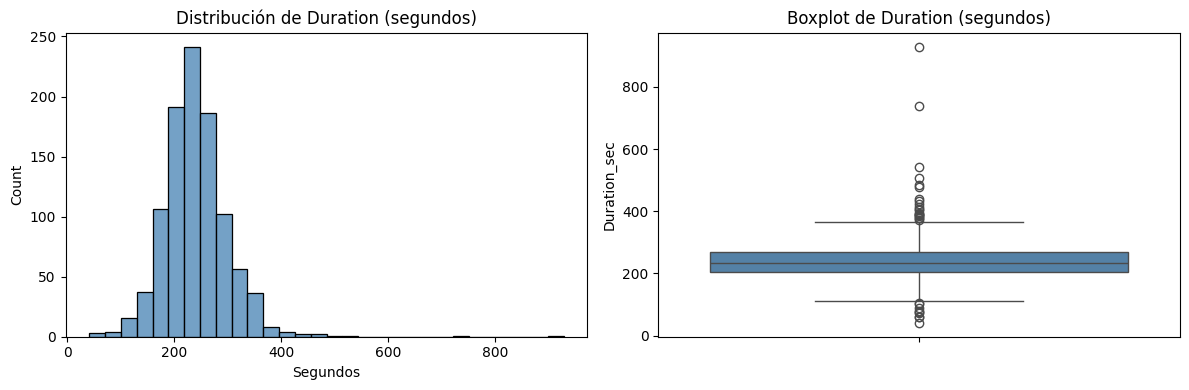

In [ ]:
# 1. Análisis de Duration
print("Tipo de Duration:", df["Duration"].dtype)
print("Ejemplos:", df["Duration"].head(10).tolist())

# Conversión a segundos
def dur_to_sec(d):
    partes = d.split(":")
    return int(partes[0]) * 60 + int(partes[1])

df["Duration_sec"] = df["Duration"].apply(dur_to_sec)
print("\nDuration en segundos:")
print(df["Duration_sec"].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Duration_sec"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de Duration (segundos)")
axes[0].set_xlabel("Segundos")
sns.boxplot(y=df["Duration_sec"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot de Duration (segundos)")
plt.tight_layout()
plt.show()

**Respuesta:** Convertirla a segundos y almacenarla como variable numérica.

- `Duration` tiene formato `mm:ss` (texto). No es categórica con cardinalidad baja, por lo que one-hot encoding generaría cientos de columnas sin sentido.
- Tampoco es una categoría ordinal que deba mantenerse como tal.
- La conversión a segundos conserva la información ordinal y numérica, permitiendo que los modelos la interpreten correctamente.

---
## Pregunta 2: Estrategia para Track y Artist como predictores

Si quisiéramos usar el nombre de la pista o el artista como predictores, debemos decidir cómo codificar estas variables categóricas de alta cardinalidad.

In [ ]:
# 2. Cardinalidad de Track y Artist
print("Tracks unicos:", df["Track"].nunique(), "/", len(df), "registros")
print("Artists unicos:", df["Artist"].nunique(), "/", len(df), "registros")

print("\nTop 10 artistas mas frecuentes:")
print(df["Artist"].value_counts().head(10).to_string())

n_cols = df["Track"].nunique() + df["Artist"].nunique()
print("\nOne-hot encoding crearia", n_cols, "columnas (demasiadas!)")

Tracks unicos: 972 / 998 registros
Artists unicos: 475 / 998 registros

Top 10 artistas mas frecuentes:
Artist
Madonna                    17
Daryl Hall & John Oates    13
Michael Jackson            13
Lionel Richie              12
Prince                     11
Elton John                  9
Stevie Wonder               9
Bruce Springsteen           9
Billy Joel                  9
Huey Lewis and the News     9

One-hot encoding crearia 1447 columnas (demasiadas!)


**Respuesta:** Utilizar técnicas como frequency encoding o target encoding.

- **One-hot encoding** crearía ~1447 columnas (972 tracks + 475 artistas), una dimensión enorme para 998 registros.
- **Enteros arbitrarios** introducirían un orden falso.
- **Frequency encoding** (reemplazar cada categoría por su frecuencia) o **target encoding** (reemplazar por la media del target) son las estrategias más adecuadas para variables con alta cardinalidad.

---
## Pregunta 3: Discretización — cuantiles vs intervalos de igual amplitud

Comparamos cómo se distribuyen los datos al dividir en 4 bins usando **quantiles** (frecuencias iguales) vs **intervalos de igual amplitud** (ancho de bin fijo). La mayor diferencia ocurre en la variable más sesgada.

In [ ]:
# 3. Comparación de discretizaciones
print("{:<15} {:>10} {:>6} {:>6} {:>12}".format("Variable","Skewness","Q","EW","Diferencia"))
print("-" * 55)

for col in ["Speechiness", "Energy", "Danceability", "Popularity"]:
    s = df[col].dropna()
    sk = skew(s)
    q_bins = pd.qcut(s, 4, duplicates="drop")
    e_bins = pd.cut(s, 4)
    q_counts = q_bins.value_counts().sort_index().tolist()
    e_counts = e_bins.value_counts().sort_index().tolist()
    # La diferencia máxima entre los conteos de bins
    diff = max(abs(qc - ec) for qc, ec in zip(q_counts, e_counts))
    print(f"{col:<15} {sk:>+10.3f} {q_bins.nunique():>6} {e_bins.nunique():>6} {diff:>12}")

Variable          Skewness      Q     EW   Diferencia
-------------------------------------------------------
Speechiness         +3.938      4      4          694
Energy              -0.440      4      4          206
Danceability        -0.312      4      4          237
Popularity          -0.976      4      4          322


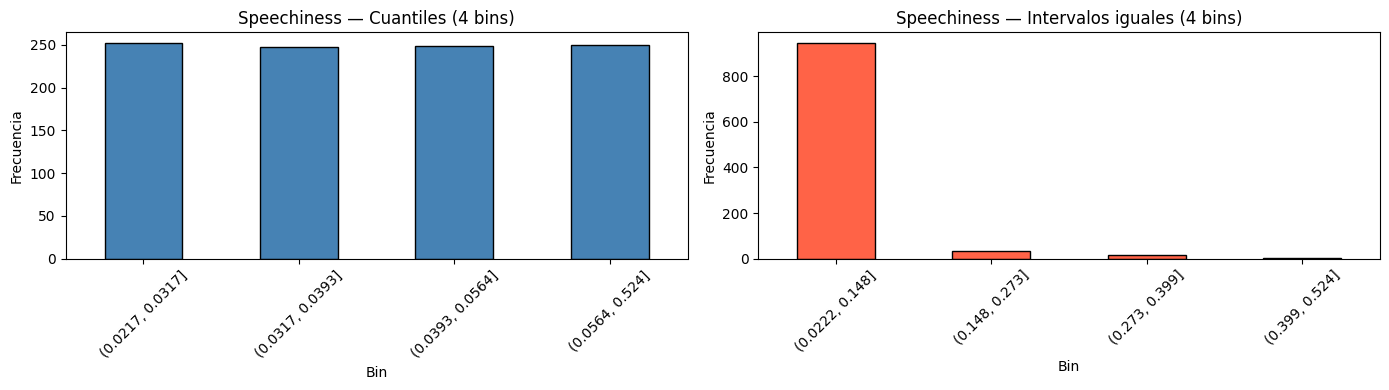

Cuantiles: [252, 247, 249, 250]
Iguales:  [946, 33, 16, 3]


In [ ]:
# Detalle visual de Speechiness (la más diferenciada)
s = df["Speechiness"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

q_bins = pd.qcut(s, 4)
e_bins = pd.cut(s, 4)

q_counts = q_bins.value_counts().sort_index()
e_counts = e_bins.value_counts().sort_index()

q_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Speechiness — Cuantiles (4 bins)")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis="x", rotation=45)

e_counts.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Speechiness — Intervalos iguales (4 bins)")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Cuantiles:", q_counts.tolist())
print("Iguales: ", e_counts.tolist())

**Respuesta:** Speechiness.

- `Speechiness` tiene skewness = +3.94 (muy sesgada a la derecha): la mayoría de las canciones tienen speechiness cercano a 0.
- Con **cuantiles** los 4 bins tienen ~250 registros cada uno (distribución uniforme).
- Con **intervalos iguales** el primer bin contiene 946 de 998 registros (95%).
- Esta enorme diferencia (946 vs 252) es la mayor entre las 4 variables.

---
## Pregunta 4: Balance de la variable Mode

`Mode` es una variable binaria (0 o 1) que indica si la canción está en modo mayor (1) o menor (0).

Conteo de Mode:
Mode
0    310
1    688

Balance: 68.9% (modo mayor) / 31.1% (modo menor)


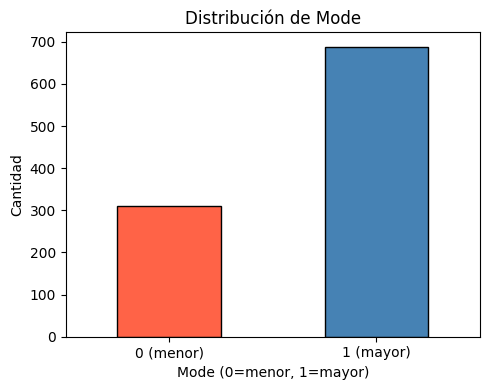

In [ ]:
# 4. Balance de Mode
vc = df["Mode"].value_counts().sort_index()
print("Conteo de Mode:")
print(vc.to_string())

pct_0 = 100 * vc[0] / len(df)
pct_1 = 100 * vc[1] / len(df)
print("\nBalance: {:.1f}% (modo mayor) / {:.1f}% (modo menor)".format(pct_1, pct_0))

fig, ax = plt.subplots(figsize=(5, 4))
vc.plot(kind="bar", ax=ax, color=["tomato", "steelblue"], edgecolor="black")
ax.set_title("Distribución de Mode")
ax.set_xlabel("Mode (0=menor, 1=mayor)")
ax.set_ylabel("Cantidad")
ax.set_xticklabels(["0 (menor)", "1 (mayor)"], rotation=0)
plt.tight_layout()
plt.show()

**Respuesta:** Desbalanceada (~69% / 31%); conviene stratify en el split y considerar SMOTE/undersampling si el desempeño en la clase minoritaria es pobre.

- No está "perfectamente balanceada" (50/50): la clase 1 (mayor) tiene ~69% y la clase 0 (menor) ~31%.
- Tampoco está "tan desbalanceada" (>95% en una clase) como para descartarla.
- Con un 31% en la clase minoritaria, el desbalance es moderado: conviene usar `stratify` en el train/test split y considerar técnicas de balanceo (SMOTE, undersampling) si el modelo tiene bajo rendimiento en la clase minoritaria.

---
## Resumen de respuestas

In [ ]:
print("P1 — Transformación de Duration: Convertirla a segundos y almacenarla como variable numérica.")
print("P2 — Track y Artist como predictores: Utilizar técnicas como frequency encoding o target encoding.")
print("P3 — Mayor diferencia cuantiles vs iguales: Speechiness (skewness = {:.2f})".format(skew(df["Speechiness"])))
print("P4 — Balance de Mode: Desbalanceada (~{:.0f}% / {:.0f}%)".format(pct_1, pct_0))

P1 — Transformación de Duration: Convertirla a segundos y almacenarla como variable numérica.
P2 — Track y Artist como predictores: Utilizar técnicas como frequency encoding o target encoding.
P3 — Mayor diferencia cuantiles vs iguales: Speechiness (skewness = 3.94)
P4 — Balance de Mode: Desbalanceada (~69% / 31%)
